# Hard Drive Failure Prediction

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/backblaze/hard-drive-test-data/harddrive.csv


In [2]:
import os
os.makedirs('/kaggle/working/images', exist_ok=True)

# Dataset Exploration

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/backblaze/hard-drive-test-data/harddrive.csv')

In [4]:
df.head()

,date,serial_number,model,capacity_bytes,failure,smart_1_normalized,smart_1_raw,smart_2_normalized,smart_2_raw,smart_3_normalized,...,smart_250_normalized,smart_250_raw,smart_251_normalized,smart_251_raw,smart_252_normalized,smart_252_raw,smart_254_normalized,smart_254_raw,smart_255_normalized,smart_255_raw
0,2016-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,135.0,108.0,143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-01,Z305B2QN,ST4000DM000,1.976651e-311,0,113,54551400,NaN,NaN,96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,136.0,104.0,124,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,1.482490e-311,0,100,0,136.0,104.0,137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-01,WD-WMC4N2899475,WDC WD30EFRX,1.482490e-311,0,200,0,NaN,NaN,175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(3179295, 95)

In [6]:
df.dtypes

date                     object
serial_number            object
model                    object
capacity_bytes          float64
failure                   int64
                         ...   
smart_252_raw           float64
smart_254_normalized    float64
smart_254_raw           float64
smart_255_normalized    float64
smart_255_raw           float64
Length: 95, dtype: object

In [7]:
df['failure'].value_counts()

failure
0    3179080
1        215
Name: count, dtype: int64

# Feature Engineering

## Handling NULL values

In [8]:
df.isnull().sum().sort_values(ascending=False).head(20)

smart_15_raw            3179295
smart_15_normalized     3179295
smart_255_raw           3179295
smart_255_normalized    3179295
smart_201_normalized    3179289
smart_13_normalized     3179289
smart_13_raw            3179289
smart_201_raw           3179289
smart_22_normalized     3176955
smart_22_raw            3176955
smart_250_normalized    3176460
smart_250_raw           3176460
smart_252_normalized    3176460
smart_251_normalized    3176460
smart_251_raw           3176460
smart_252_raw           3176460
smart_254_raw           3171360
smart_254_normalized    3171360
smart_222_raw           3169385
smart_222_normalized    3169385
dtype: int64

In [9]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending = False)
print(null_percent)

smart_15_raw            100.000000
smart_15_normalized     100.000000
smart_255_raw           100.000000
smart_255_normalized    100.000000
smart_201_normalized     99.999811
                           ...    
smart_193_raw             1.342310
smart_192_normalized      0.301356
smart_192_raw             0.301356
smart_194_raw             0.001636
smart_194_normalized      0.001636
Length: 64, dtype: float64


In [10]:
print(f"\nColumns with >50% nulls: {(null_percent > 50).sum()}")
print(f"Columns with >90% nulls: {(null_percent > 90).sum()}")


Columns with >50% nulls: 42
Columns with >90% nulls: 36


In [11]:
print(df[['date', 'serial_number', 'model', 'failure']].head(10))

         date    serial_number                    model  failure
0  2016-01-01   MJ0351YNG9Z0XA  Hitachi HDS5C3030ALA630        0
1  2016-01-01         Z305B2QN              ST4000DM000        0
2  2016-01-01   MJ0351YNG9Z7LA  Hitachi HDS5C3030ALA630        0
3  2016-01-01   MJ0351YNGABYAA  Hitachi HDS5C3030ALA630        0
4  2016-01-01  WD-WMC4N2899475             WDC WD30EFRX        0
5  2016-01-01   PL1321LAG34XWH  Hitachi HDS5C4040ALE630        0
6  2016-01-01   MJ1323YNG1TJ7C  Hitachi HDS5C3030ALA630        0
7  2016-01-01         S300Z6K9              ST4000DM000        0
8  2016-01-01         S300Z6K8              ST4000DM000        0
9  2016-01-01         Z302PGH8              ST4000DM000        0


In [12]:
cols_to_drop_nulls = null_percent[null_percent > 90].index

## Handling Normalized Columns

In [13]:
cols_normalized = [col for col in df.columns if 'normalized' in col]

In [14]:
cols_to_drop = list(cols_to_drop_nulls) + cols_normalized

In [15]:
df = df.drop(cols_to_drop, axis=1)

In [16]:
df.shape

(3179295, 32)

In [17]:
print(df.columns.tolist())

['date', 'serial_number', 'model', 'capacity_bytes', 'failure', 'smart_1_raw', 'smart_2_raw', 'smart_3_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_8_raw', 'smart_9_raw', 'smart_10_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']


In [18]:
print(df.isnull().sum().sum())

13900446


## Handling Remaining Nulls & dtype Fixes

In [19]:
df.fillna('0', inplace=True)

/tmp/ipykernel_58/1746905826.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('0', inplace=True)


In [20]:
print(df.select_dtypes(include='object').columns.tolist())

['date', 'serial_number', 'model', 'smart_2_raw', 'smart_8_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw']


In [21]:
print(df['smart_187_raw'].unique()[:20])

['0' 0.0 1.0 6.0 21.0 10.0 12.0 27.0 7.0 22.0 4.0 2.0 3.0 13.0 30.0 39.0
 9.0 5.0 8.0 28.0]


In [22]:
object_smart_cols = ['smart_2_raw', 'smart_8_raw', 'smart_183_raw', 'smart_184_raw', 
                     'smart_187_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw', 
                     'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw']

df[object_smart_cols] = df[object_smart_cols].apply(pd.to_numeric, errors='coerce')

In [23]:
df[object_smart_cols] = df[object_smart_cols].fillna(0.0)

In [24]:
print(df.select_dtypes(include='object').columns.tolist())
print(df.isnull().sum().sum())

['date', 'serial_number', 'model']
0


In [25]:
df[df['failure']==1]

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_192_raw,smart_193_raw,smart_194_raw,smart_196_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
30285,2016-01-01,WD-WCC4MKDL77ZK,WDC WD20EFRX,9.883284e-312,1,0,0.0,0,4,0,...,2.0,571.0,27.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00
31847,2016-01-01,Z300KHN0,ST4000DM000,1.976651e-311,1,26281840,0.0,0,12,0,...,5.0,15789.0,24.0,0.0,40,40,0,6.255644e-310,1.168777e-313,1.126168e-312
37041,2016-01-01,Z3015V4D,ST4000DM000,1.976651e-311,1,88716600,0.0,0,25,0,...,13.0,73805.0,27.0,0.0,56,56,3,7.830940e-320,1.103291e-313,1.512541e-312
46720,2016-01-01,W3006E5B,ST4000DM000,1.976651e-311,1,143154896,0.0,0,22,0,...,5.0,75868.0,22.0,0.0,0,0,2,8.281937e-310,1.234518e-313,1.316288e-312
87830,2016-01-01,WD-WCC4MKDL77ZK,WDC WD20EFRX,9.883284e-312,1,0,0.0,0,4,0,...,2.0,571.0,27.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084227,2016-04-28,W0Q6KWV8,ST320LT007,1.581370e-312,1,147958432,0.0,0,20,121,...,1.0,157829.0,26.0,0.0,0,0,0,1.938655e-310,4.047112e-315,3.733211e-315
3100634,2016-04-28,S300XP36,ST4000DM000,1.976651e-311,1,146527232,0.0,0,2,0,...,0.0,38355.0,23.0,0.0,0,0,0,4.058255e-320,1.360172e-313,7.902839e-314
3105860,2016-04-28,W300T2RC,ST4000DM000,1.976651e-311,1,144495808,0.0,0,13,0,...,2.0,61051.0,37.0,0.0,24,24,0,9.588826e-320,8.115515e-314,5.084032e-313
3136939,2016-04-29,Z302A13D,ST4000DM000,1.976651e-311,1,223384952,0.0,0,3,0,...,0.0,49077.0,20.0,0.0,8,8,0,5.221780e-320,1.574255e-313,1.112712e-313


In [26]:
df['date'] = pd.to_datetime(df['date'])

In [27]:
print(df['date'].dtype)
print(df['date'].head(3))

datetime64[ns]
0   2016-01-01
1   2016-01-01
2   2016-01-01
Name: date, dtype: datetime64[ns]


# Target Label Engineering
## Defining 30-Day Failure Window

In [28]:
#first failure of each drive
failure_dates = df[df['failure'] == 1].groupby('serial_number')['date'].min()

In [29]:
# mapping of each row with its failure date from failure_dates using serial_number as key
df['failure_date'] = df['serial_number'].map(failure_dates)

In [30]:
print(df['failure_date'].isnull().sum())
print(df['failure_date'].notnull().sum())
# 5490 is the total rows of the failed drive with the rows exceeding (before) the 30 days range

3173805
5490


In [31]:
df[df['failure']==1]

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_193_raw,smart_194_raw,smart_196_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,failure_date
30285,2016-01-01,WD-WCC4MKDL77ZK,WDC WD20EFRX,9.883284e-312,1,0,0.0,0,4,0,...,571.0,27.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,2016-01-01
31847,2016-01-01,Z300KHN0,ST4000DM000,1.976651e-311,1,26281840,0.0,0,12,0,...,15789.0,24.0,0.0,40,40,0,6.255644e-310,1.168777e-313,1.126168e-312,2016-01-01
37041,2016-01-01,Z3015V4D,ST4000DM000,1.976651e-311,1,88716600,0.0,0,25,0,...,73805.0,27.0,0.0,56,56,3,7.830940e-320,1.103291e-313,1.512541e-312,2016-01-01
46720,2016-01-01,W3006E5B,ST4000DM000,1.976651e-311,1,143154896,0.0,0,22,0,...,75868.0,22.0,0.0,0,0,2,8.281937e-310,1.234518e-313,1.316288e-312,2016-01-01
87830,2016-01-01,WD-WCC4MKDL77ZK,WDC WD20EFRX,9.883284e-312,1,0,0.0,0,4,0,...,571.0,27.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,2016-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3084227,2016-04-28,W0Q6KWV8,ST320LT007,1.581370e-312,1,147958432,0.0,0,20,121,...,157829.0,26.0,0.0,0,0,0,1.938655e-310,4.047112e-315,3.733211e-315,2016-04-28
3100634,2016-04-28,S300XP36,ST4000DM000,1.976651e-311,1,146527232,0.0,0,2,0,...,38355.0,23.0,0.0,0,0,0,4.058255e-320,1.360172e-313,7.902839e-314,2016-04-28
3105860,2016-04-28,W300T2RC,ST4000DM000,1.976651e-311,1,144495808,0.0,0,13,0,...,61051.0,37.0,0.0,24,24,0,9.588826e-320,8.115515e-314,5.084032e-313,2016-04-28
3136939,2016-04-29,Z302A13D,ST4000DM000,1.976651e-311,1,223384952,0.0,0,3,0,...,49077.0,20.0,0.0,8,8,0,5.221780e-320,1.574255e-313,1.112712e-313,2016-04-29


In [32]:
df[df['serial_number']=='JK11A8B9J90WMF']

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_193_raw,smart_194_raw,smart_196_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,failure_date
22006,2016-01-01,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1105.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
79551,2016-01-01,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1105.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
137098,2016-01-02,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1105.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
194668,2016-01-03,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1106.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
252273,2016-01-04,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1107.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
309857,2016-01-05,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1107.0,40.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
367397,2016-01-06,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1108.0,40.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
424910,2016-01-07,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1109.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
482426,2016-01-08,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1110.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29
539942,2016-01-09,JK11A8B9J90WMF,Hitachi HDS722020ALA330,9.883284e-312,0,0,0.0,612,19,53,...,1111.0,39.0,53.0,0,0,0,0.0,0.0,0.0,2016-04-29


In [33]:
df['failure_in_30days'] = np.where((df['failure_date'].notna()) & (df['date'] >= df['failure_date'] - pd.Timedelta(days=30)), 1, 0)

In [34]:
print(df['failure_in_30days'].value_counts())
# 2960 is the number of failed drive rows within the range of 30 days

failure_in_30days
0    3176335
1       2960
Name: count, dtype: int64


In [35]:
sample_drive = failure_dates.index[0]
print(sample_drive)

13H883WAS


In [36]:
sample = df[df['serial_number'] == sample_drive][['date', 'failure', 'failure_in_30days']].sort_values('date')
print(sample.tail(40))

              date  failure  failure_in_30days
219018  2016-01-03        0                  0
276625  2016-01-04        0                  0
334191  2016-01-05        0                  0
391714  2016-01-06        0                  0
449229  2016-01-07        0                  0
506745  2016-01-08        0                  0
564260  2016-01-09        0                  0
621775  2016-01-10        0                  0
679291  2016-01-11        0                  0
736806  2016-01-12        0                  0
794322  2016-01-13        0                  0
851839  2016-01-14        0                  0
909392  2016-01-15        0                  0
966915  2016-01-16        0                  0
1024429 2016-01-17        0                  0
1081930 2016-01-18        0                  0
1139438 2016-01-19        0                  0
1196954 2016-01-20        0                  0
1254431 2016-01-21        0                  0
1316385 2016-04-01        0                  1
1379337 2016-

## Deduplication

In [37]:
dupes = df.groupby(['serial_number', 'date']).size()
print(dupes[dupes > 1].count())

120497


In [38]:
# Pick one duplicate and inspect it
sample_dupe = df.groupby(['serial_number', 'date']).size()
sample_dupe = sample_dupe[sample_dupe > 1].index[0]

print(df[(df['serial_number'] == sample_dupe[0]) & 
         (df['date'] == sample_dupe[1])])

             date serial_number               model  capacity_bytes  failure  \
56653  2016-01-01     13H2B97AS  TOSHIBA DT01ACA300   1.482490e-311        0   
114198 2016-01-01     13H2B97AS  TOSHIBA DT01ACA300   1.482490e-311        0   

        smart_1_raw  smart_2_raw  smart_3_raw  smart_4_raw  smart_5_raw  ...  \
56653        131072         75.0          429           18            0  ...   
114198       131072         75.0          429           18            0  ...   

        smart_194_raw  smart_196_raw  smart_197_raw  smart_198_raw  \
56653            32.0            0.0              0              0   
114198           32.0            0.0              0              0   

        smart_199_raw  smart_240_raw  smart_241_raw  smart_242_raw  \
56653              10            0.0            0.0            0.0   
114198             10            0.0            0.0            0.0   

        failure_date  failure_in_30days  
56653            NaT                  0  
114198      

## Dropping Corrupted `capacity_bytes` Column

In [39]:
print(df['capacity_bytes'].describe())
print(df['capacity_bytes'].value_counts().head(10))

count     3.179295e+06
mean     1.849552e-311
std       0.000000e+00
min      3.953828e-313
25%      1.976651e-311
50%      1.976651e-311
75%      1.976651e-311
max      3.953298e-311
Name: capacity_bytes, dtype: float64
capacity_bytes
1.976651e-311    2400071
1.482490e-311     346271
9.883284e-312     231563
2.964974e-311     121680
2.470861e-312      47771
7.907120e-313      10044
1.235457e-312       5184
1.581370e-312       4654
7.412476e-312       4456
3.953298e-311       2340
Name: count, dtype: int64


In [40]:
df = df.drop(columns=['capacity_bytes'])

In [41]:
df = df.drop_duplicates(subset=['serial_number','date'], keep='first')

In [42]:
df.shape

(3058798, 33)

In [43]:
print(df['failure_in_30days'].value_counts())
print(f"Positive rate: {df['failure_in_30days'].mean()*100:.4f}%")

failure_in_30days
0    3056039
1       2759
Name: count, dtype: int64
Positive rate: 0.0902%


In [44]:
df

,date,serial_number,model,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,...,smart_194_raw,smart_196_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,failure_date,failure_in_30days
0,2016-01-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,0,0,108.0,540,14,0,0.000000e+00,...,20.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,NaT,0
1,2016-01-01,Z305B2QN,ST4000DM000,0,54551400,0.0,0,4,0,1.279800e-317,...,30.0,0.0,0,0,0,1.319155e-321,3.467963e-315,1.316882e-315,NaT,0
2,2016-01-01,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,0,0,104.0,566,19,0,0.000000e+00,...,24.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,NaT,0
3,2016-01-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,0,0,104.0,507,15,0,0.000000e+00,...,31.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,NaT,0
4,2016-01-01,WD-WMC4N2899475,WDC WD30EFRX,0,0,0.0,6250,10,0,0.000000e+00,...,29.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,NaT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3179290,2016-04-29,MJ1311YNG3G5NA,Hitachi HDS5C3030ALA630,0,0,0.0,568,20,0,0.000000e+00,...,33.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,NaT,0
3179291,2016-04-29,Z3016V0V,ST4000DM000,0,121623392,0.0,0,11,0,1.415864e-316,...,23.0,0.0,0,0,0,9.361062e-320,1.432235e-313,1.849892e-312,NaT,0
3179292,2016-04-29,MJ1323YNG1LZJC,Hitachi HDS5C3030ALA630,0,0,0.0,563,21,0,0.000000e+00,...,28.0,0.0,0,0,0,0.000000e+00,0.000000e+00,0.000000e+00,NaT,0
3179293,2016-04-29,S300YQXW,ST4000DM000,0,179727616,0.0,0,4,0,1.151235e-315,...,36.0,0.0,0,0,0,3.214885e-320,1.187203e-313,1.456773e-314,NaT,0


## Drive Age Feature

In [45]:
df = df.sort_values(by = ['serial_number','date']).reset_index(drop=True)

In [46]:
 print(df.head(5)[['serial_number', 'date']])

  serial_number       date
0     13H2B97AS 2016-01-01
1     13H2B97AS 2016-01-02
2     13H2B97AS 2016-01-03
3     13H2B97AS 2016-01-04
4     13H2B97AS 2016-01-05


In [47]:
df['drive_age_days'] = df.groupby('serial_number')['date'].transform(
    lambda date: (date - date.min()).dt.days
)

In [48]:
print(df[['serial_number', 'date', 'drive_age_days']].head(10))

  serial_number       date  drive_age_days
0     13H2B97AS 2016-01-01               0
1     13H2B97AS 2016-01-02               1
2     13H2B97AS 2016-01-03               2
3     13H2B97AS 2016-01-04               3
4     13H2B97AS 2016-01-05               4
5     13H2B97AS 2016-01-06               5
6     13H2B97AS 2016-01-07               6
7     13H2B97AS 2016-01-08               7
8     13H2B97AS 2016-01-09               8
9     13H2B97AS 2016-01-10               9


## Delta and Rolling-Average Features

In [49]:
smart_cols = ['smart_5_raw', 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw']

for col in smart_cols:
    df[f'{col}_delta'] = df.groupby('serial_number')[col].transform(lambda smart_cols: smart_cols.diff())

In [50]:
print(df[['serial_number', 'date', 'smart_5_raw', 'smart_5_raw_delta']].head(10))

  serial_number       date  smart_5_raw  smart_5_raw_delta
0     13H2B97AS 2016-01-01            0                NaN
1     13H2B97AS 2016-01-02            0                0.0
2     13H2B97AS 2016-01-03            0                0.0
3     13H2B97AS 2016-01-04            0                0.0
4     13H2B97AS 2016-01-05            0                0.0
5     13H2B97AS 2016-01-06            0                0.0
6     13H2B97AS 2016-01-07            0                0.0
7     13H2B97AS 2016-01-08            0                0.0
8     13H2B97AS 2016-01-09            0                0.0
9     13H2B97AS 2016-01-10            0                0.0


In [51]:
for col in smart_cols:
    df[f'{col}_delta'] = df[f'{col}_delta'].fillna(0)

In [52]:
print(df[['serial_number', 'date', 'smart_5_raw', 'smart_5_raw_delta']].head(3))
print(df[[f'{col}_delta' for col in smart_cols]].isnull().sum())

  serial_number       date  smart_5_raw  smart_5_raw_delta
0     13H2B97AS 2016-01-01            0                0.0
1     13H2B97AS 2016-01-02            0                0.0
2     13H2B97AS 2016-01-03            0                0.0
smart_5_raw_delta      0
smart_187_raw_delta    0
smart_188_raw_delta    0
smart_197_raw_delta    0
smart_198_raw_delta    0
dtype: int64


In [53]:
smart_cols = ['smart_5_raw', 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw']

for col in smart_cols:
    df[f'{col}_roll_avg'] = df.groupby('serial_number')[col].transform(lambda x: x.rolling(7,min_periods=1).mean())

In [54]:
print(df[['serial_number', 'date', 'smart_5_raw', 'smart_5_raw_roll_avg']].head(10))

  serial_number       date  smart_5_raw  smart_5_raw_roll_avg
0     13H2B97AS 2016-01-01            0                   0.0
1     13H2B97AS 2016-01-02            0                   0.0
2     13H2B97AS 2016-01-03            0                   0.0
3     13H2B97AS 2016-01-04            0                   0.0
4     13H2B97AS 2016-01-05            0                   0.0
5     13H2B97AS 2016-01-06            0                   0.0
6     13H2B97AS 2016-01-07            0                   0.0
7     13H2B97AS 2016-01-08            0                   0.0
8     13H2B97AS 2016-01-09            0                   0.0
9     13H2B97AS 2016-01-10            0                   0.0


In [55]:
print(df[[f'{col}_roll_avg' for col in smart_cols]].isnull().sum())
print(df.shape)

smart_5_raw_roll_avg      0
smart_187_raw_roll_avg    0
smart_188_raw_roll_avg    0
smart_197_raw_roll_avg    0
smart_198_raw_roll_avg    0
dtype: int64
(3058798, 44)


In [56]:
pd.set_option('display.max_columns', None)
print(df.head(5))

        date serial_number               model  failure  smart_1_raw  \
0 2016-01-01     13H2B97AS  TOSHIBA DT01ACA300        0       131072   
1 2016-01-02     13H2B97AS  TOSHIBA DT01ACA300        0            1   
2 2016-01-03     13H2B97AS  TOSHIBA DT01ACA300        0            1   
3 2016-01-04     13H2B97AS  TOSHIBA DT01ACA300        0            0   
4 2016-01-05     13H2B97AS  TOSHIBA DT01ACA300        0            0   

   smart_2_raw  smart_3_raw  smart_4_raw  smart_5_raw  smart_7_raw  \
0         75.0          429           18            0          0.0   
1         75.0          429           18            0          0.0   
2         75.0          429           18            0          0.0   
3         75.0          429           18            0          0.0   
4         75.0          429           18            0          0.0   

   smart_8_raw  smart_9_raw  smart_10_raw  smart_12_raw  smart_183_raw  \
0         34.0        16274             0            18            0.0  

In [57]:
df[df['failure']==1]

,date,serial_number,model,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_8_raw,smart_9_raw,smart_10_raw,smart_12_raw,smart_183_raw,smart_184_raw,smart_187_raw,smart_188_raw,smart_189_raw,smart_190_raw,smart_191_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_196_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,failure_date,failure_in_30days,drive_age_days,smart_5_raw_delta,smart_187_raw_delta,smart_188_raw_delta,smart_197_raw_delta,smart_198_raw_delta,smart_5_raw_roll_avg,smart_187_raw_roll_avg,smart_188_raw_roll_avg,smart_197_raw_roll_avg,smart_198_raw_roll_avg
340,2016-04-20,13H883WAS,TOSHIBA DT01ACA300,1,65538,0.0,434,32,0,0.000000e+00,0.0,19476,1,31,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,781.0,781.0,27.0,0.0,32,0,157,0.000000e+00,0.000000e+00,0.000000e+00,2016-04-20,1,110,0.0,0.0,0.000000e+00,32.0,0.0,0.000000,0.000000,0.000000e+00,4.571429,0.0
12893,2016-04-04,6VMX70TB,ST3160316AS,1,7303319,0.0,0,27,0,2.230683e-315,0.0,40040,0,27,0.0,0.0,0.0,3.162020e-322,0.0,27.0,0.0,0.0,0.0,27.0,0.0,0,0,0,8.462095e-310,1.837513e-314,1.645247e-314,2016-04-04,1,94,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,3.112614e-322,0.000000,0.0
17929,2016-04-18,9VY8TC9H,ST3160318AS,1,132125595,0.0,0,54,2954,2.934117e-315,0.0,47362,0,27,0.0,0.0,0.0,3.804305e-322,0.0,31.0,0.0,0.0,0.0,31.0,0.0,0,0,0,1.215840e-309,2.309508e-316,6.733267e-315,2016-04-18,1,108,303.0,0.0,0.000000e+00,0.0,0.0,2363.285714,0.000000,3.804305e-322,0.000000,0.0
17959,2016-04-09,9VY8TCAV,ST3160318AS,1,89076072,0.0,0,36,2392,2.959909e-315,0.0,46875,0,18,0.0,0.0,0.0,2.228130e-312,0.0,30.0,0.0,0.0,0.0,30.0,0.0,0,0,0,8.994716e-310,1.739298e-315,1.891425e-314,2016-04-09,1,99,387.0,0.0,6.790490e-313,0.0,0.0,1363.857143,0.000000,8.245595e-313,0.000000,0.0
30196,2016-04-21,JK1101B9GEJEUF,Hitachi HDS722020ALA330,1,524311,0.0,641,48,25,0.000000e+00,0.0,47522,0,48,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,794.0,794.0,28.0,25.0,1,0,0,0.000000e+00,0.000000e+00,0.000000e+00,2016-04-21,1,111,0.0,0.0,0.000000e+00,0.0,0.0,22.142857,0.000000,0.000000e+00,1.714286,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2909104,2016-04-20,Z305GV9E,ST4000DM000,1,21824648,0.0,0,1,0,2.562823e-316,0.0,869,0,1,0.0,0.0,7.0,0.000000e+00,0.0,25.0,0.0,0.0,2876.0,25.0,0.0,0,0,0,4.100745e-321,4.022911e-314,1.793148e-314,2016-04-20,1,19,0.0,1.0,0.000000e+00,0.0,0.0,0.000000,6.142857,0.000000e+00,0.000000,0.0
2937766,2016-04-20,Z305K26M,ST4000DM000,1,169894560,0.0,0,1,0,2.199865e-316,0.0,870,0,1,0.0,0.0,0.0,0.000000e+00,0.0,26.0,0.0,0.0,2378.0,26.0,0.0,0,0,0,4.085923e-321,4.049743e-314,3.431540e-315,2016-04-20,1,19,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0
2953271,2016-04-19,Z305LZGQ,ST4000DM000,1,127829664,0.0,0,4,1424,2.110458e-316,0.0,847,0,4,0.0,0.0,0.0,0.000000e+00,0.0,23.0,0.0,0.0,2773.0,23.0,0.0,0,0,0,3.972288e-321,3.933033e-314,3.491931e-315,2016-04-19,1,18,1424.0,0.0,0.000000e+00,0.0,0.0,203.428571,0.000000,0.000000e+00,0.000000,0.0
2985191,2016-04-05,Z4D045CF,ST6000DX000,1,160602623,0.0,0,17,0,5.488391e-315,0.0,14566,0,15,0.0,0.0,0.0,0.000000e+00,10.0,25.0,6849.0,0.0,4266.0,25.0,0.0,0,0,0,5.989121e-310,1.320339e-313,1.176538e-310,2016-04-05,1,95,0.0,0.0,0.000000e+00,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000,0.0


# Encoding of 'model'

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['model_encoded'] = le.fit_transform(df['model'])

In [59]:
print(df.shape)
print(df.columns.tolist())
print(df['failure_in_30days'].value_counts())

(3058798, 45)
['date', 'serial_number', 'model', 'failure', 'smart_1_raw', 'smart_2_raw', 'smart_3_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_8_raw', 'smart_9_raw', 'smart_10_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw', 'failure_date', 'failure_in_30days', 'drive_age_days', 'smart_5_raw_delta', 'smart_187_raw_delta', 'smart_188_raw_delta', 'smart_197_raw_delta', 'smart_198_raw_delta', 'smart_5_raw_roll_avg', 'smart_187_raw_roll_avg', 'smart_188_raw_roll_avg', 'smart_197_raw_roll_avg', 'smart_198_raw_roll_avg', 'model_encoded']
failure_in_30days
0    3056039
1       2759
Name: count, dtype: int64


# Data split

In [60]:
train = df[df['date'] < '2016-04-01']
test = df[df['date'] >= '2016-04-01']

In [61]:
feature_cols = ['smart_1_raw', 'smart_2_raw', 'smart_3_raw', 'smart_4_raw', 
                'smart_5_raw', 'smart_7_raw', 'smart_8_raw', 'smart_9_raw', 'smart_10_raw',
                'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 
                'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw', 
                'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_196_raw', 
                'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 
                'smart_241_raw', 'smart_242_raw', 'drive_age_days', 'smart_5_raw_delta', 
                'smart_187_raw_delta', 'smart_188_raw_delta', 'smart_197_raw_delta', 
                'smart_198_raw_delta', 'smart_5_raw_roll_avg', 'smart_187_raw_roll_avg', 
                'smart_188_raw_roll_avg', 'smart_197_raw_roll_avg', 'smart_198_raw_roll_avg', 'model_encoded']
X_train = train[feature_cols]
y_train = train['failure_in_30days']
X_test = test[feature_cols]
y_test = test['failure_in_30days']

In [62]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(1208081, 39) (1850717, 39)
failure_in_30days
0    1207283
1        798
Name: count, dtype: int64
failure_in_30days
0    1848756
1       1961
Name: count, dtype: int64


In [63]:
print(f"Train positive rate: {y_train.mean()*100:.4f}%")
print(f"Test positive rate: {y_test.mean()*100:.4f}%")

Train positive rate: 0.0661%
Test positive rate: 0.1060%


In [64]:
df['model_encoded']

0          31
1          31
2          31
3          31
4          31
           ..
3058793    26
3058794    26
3058795    26
3058796    26
3058797    26
Name: model_encoded, Length: 3058798, dtype: int64

In [65]:
print(X_train.shape, X_test.shape)
print('model_encoded' in X_train.columns)

(1208081, 39) (1850717, 39)
True


# Logistic Regression

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [67]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1208081, 39)
(1850717, 39)


In [68]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [69]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [70]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_lr):.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.02      0.07      0.03      1961

    accuracy                           1.00   1850717
   macro avg       0.51      0.53      0.51   1850717
weighted avg       1.00      1.00      1.00   1850717

ROC-AUC: 0.7474
PR-AUC: 0.0079


# Random Forest

In [71]:
from sklearn.ensemble import RandomForestClassifier
rf =  RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [72]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [73]:
print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_rf):.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.00      0.00      0.00      1961

    accuracy                           1.00   1850717
   macro avg       0.50      0.50      0.50   1850717
weighted avg       1.00      1.00      1.00   1850717

ROC-AUC: 0.5956
PR-AUC: 0.0140


In [74]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f"Max failure probability predicted: {y_prob_rf.max():.4f}")
print(f"Mean failure probability predicted: {y_prob_rf.mean():.6f}")

Max failure probability predicted: 0.3700
Mean failure probability predicted: 0.000181


## Threshold Tuning

In [75]:
# Lower threshold to 0.1
y_pred_rf_tuned = (y_prob_rf >= 0.10).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.13      0.02      0.03      1961

    accuracy                           1.00   1850717
   macro avg       0.56      0.51      0.51   1850717
weighted avg       1.00      1.00      1.00   1850717



In [76]:
y_pred_rf_tuned = (y_prob_rf >= 0.05).astype(int)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.11      0.06      0.08      1961

    accuracy                           1.00   1850717
   macro avg       0.56      0.53      0.54   1850717
weighted avg       1.00      1.00      1.00   1850717



# XGBoost — Initial Run

In [77]:
scale_pos_weight = 1207283 / 798 
print(scale_pos_weight)

1512.8859649122808


In [78]:
import xgboost 
xgb = xgboost.XGBClassifier(scale_pos_weight=1513, n_estimators=100, random_state=42, eval_metric='aucpr')
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [79]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [80]:
print(classification_report(y_test, y_pred_xgb))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_xgb):.4f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.00      0.00      0.00      1961

    accuracy                           1.00   1850717
   macro avg       0.50      0.50      0.50   1850717
weighted avg       1.00      1.00      1.00   1850717

ROC-AUC: 0.6068
PR-AUC: 0.0042


# Diagnosing the Ranking Failure

Initial XGBoost run shows 0% recall on the positive class and PR-AUC below the
Logistic Regression baseline — indicating a ranking failure, not a threshold problem.
Investigating feature-level signal below.

In [81]:
probs = xgb.predict_proba(X_test)[:, 1]  # probability of class 1
import numpy as np
print(probs.max())
print(np.percentile(probs, [99, 99.9, 99.99]))
print(np.percentile(probs[y_test == 1],[10, 25, 50, 75, 90]))  

0.9892286
[0.00208167 0.03977791 0.22199278]
[4.22775145e-07 1.77340382e-06 9.60185207e-06 1.87830738e-04
 1.27834035e-03]


In [82]:
for col in ['smart_5_raw', 'smart_187_raw', 'smart_188_raw', 'smart_197_raw', 'smart_198_raw']:
    print(col)
    print(df[df.failure==1][col].describe())
    print(df[df.failure==0][col].describe())

smart_5_raw
count      205.000000
mean       354.482927
std       3879.393514
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      55360.000000
Name: smart_5_raw, dtype: float64
count    3.058593e+06
mean     2.019557e+00
std      1.335311e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.520000e+04
Name: smart_5_raw, dtype: float64
smart_187_raw
count      205.000000
mean       328.629268
std       4577.653290
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      65535.000000
Name: smart_187_raw, dtype: float64
count    3.058593e+06
mean     1.848834e-01
std      9.553940e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.553500e+04
Name: smart_187_raw, dtype: float64
smart_188_raw
count     2.050000e+02
mean     1.107595e-314
std       0.000000e+00
min       0.000000e+00
25%       0.000000e+00
5

In [83]:
df['smart_188_raw'].dtype

dtype('float64')

In [84]:
import sys; 
print(sys.float_info.min)

2.2250738585072014e-308


In [85]:
np.array([1], dtype=np.int64).view(np.float64)

array([5.e-324])

In [86]:
recovered = df['smart_188_raw'].values.view(np.int64)
print(recovered[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [87]:
mask = df['smart_188_raw'] != 0
recovered = df.loc[mask, 'smart_188_raw'].values.view(np.int64)
np.unique(recovered)

array([            1,             2,             3,             4,
                   5,             6,             7,             8,
                   9,            10,            11,            12,
                  13,            14,            15,            16,
                  17,            18,            19,            20,
                  21,            22,            23,            24,
                  25,            26,            27,            28,
                  29,            30,            31,            32,
                  33,            34,            35,            36,
                  37,            38,            39,            40,
                  41,            42,            43,            44,
                  45,            46,            47,            48,
                  49,            50,            51,            52,
                  53,            54,            55,            56,
                  57,            58,            59,           

In [88]:
np.array([np.nan]).view(np.int64)

array([9221120237041090560])

In [89]:
np.array([0.0]).view(np.int64)

array([0])

## Root Cause Confirmed: dtype Reinterpretation Bug

The subnormal-float pattern above (`std == 0.0`, means on the order of 1e-314) is not
statistical noise — it's the signature of integer bytes being bit-reinterpreted as
float64 upstream in the source file, rather than properly converted. Confirmed by
reversing the operation with `.view(np.int64)`, which recovers plausible integer SMART
readings.

Affected columns: `smart_7_raw`, `smart_188_raw`, `smart_240_raw`, `smart_241_raw`,
`smart_242_raw`. None of these columns had genuine missing values in the raw source —
every row held a real-but-corrupted value, so the recovery below applies cleanly with
no null-handling tradeoff required.

In [90]:
def recover_corrupted_column(df, col):
    mask_nan = df[col].isna()
    recovered = pd.Series(index=df.index, dtype='Int64')
    recovered[~mask_nan] = df.loc[~mask_nan, col].values.view(np.int64)
    return recovered

corrupt_cols = ['smart_7_raw', 'smart_188_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']

for col in corrupt_cols:
    df[col] = recover_corrupted_column(df, col)

In [91]:
df['smart_188_raw'].isna().groupby(df['failure']).mean()

failure
0    0.0
1    0.0
Name: smart_188_raw, dtype: float64

In [92]:
df[['smart_7_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']].isna().sum()

smart_7_raw      0
smart_240_raw    0
smart_241_raw    0
smart_242_raw    0
dtype: int64

In [93]:
df.describe(include='all')

,date,serial_number,model,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_8_raw,smart_9_raw,smart_10_raw,smart_12_raw,smart_183_raw,smart_184_raw,smart_187_raw,smart_188_raw,smart_189_raw,smart_190_raw,smart_191_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_196_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,failure_date,failure_in_30days,drive_age_days,smart_5_raw_delta,smart_187_raw_delta,smart_188_raw_delta,smart_197_raw_delta,smart_198_raw_delta,smart_5_raw_roll_avg,smart_187_raw_roll_avg,smart_188_raw_roll_avg,smart_197_raw_roll_avg,smart_198_raw_roll_avg,model_encoded
count,3058798,3058798,3058798,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3058798.0,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3058798.0,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3058798.0,3058798.0,3058798.0,5174,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06,3.058798e+06
unique,NaN,65993,69,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Z4D2B5EC,ST4000DM000,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,50,1617720,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2016-03-08 12:38:23.719041280,NaN,NaN,6.701979e-05,6.859435e+07,2.968559e+01,3.655422e+02,1.353109e+01,2.043179e+00,9310991473.164608,1.157466e+01,1.595446e+04,2.526311e+01,1.130606e+01,2.525064e+00,2.777562e-03,2.068956e-01,111040226.656322,8.087926e+00,1.543575e+01,3.053361e+02,1.657653e+02,1.409721e+04,2.773497e+01,8.079945e-01,8.457178e-02,7.423831e-02,2.658388e+01,10810422547383.423828,11091698844.141315,48575748916.416267,2016-04-03 12:53:42.883648512,9.019883e-04,6.129765e+01,3.520926e-02,7.166214e-04,-2.124965e-317,6.367207e-03,7.306792e-04,1.942926e+00,2.060123e-01,6.132723e-316,7.884906e-02,7.317741e-02,1.787352e+01
min,2016-01-01 00:00:00,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.0,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,2016-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.413819e-311,-1.592000e+03,-1.592000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2016-01-14 00:00:00,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.0,0.000000e+00,5.692000e+03,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.970000e+02,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,2016-04-05 00:00:00,0.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00
50%,2016-04-06 00:00:00,NaN,NaN,0.000000e+00,2.981241e+07,0.000000e+00,0.000000e+00,7.000000e+00,0.000000e+00,72159383.0,0.000000e+00,1.368800e+04,0.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,2.100000e+01,0.000000e+00,3.000000e+00,2.355000e+03,2.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1624.0,10548449880.0,967967421.0,2016-04-18 00:00:00,0.000000e+00,9.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.00000

In [94]:
print(df.isnull().sum().sum())

3053624


## Rebuilding Downstream Features After Recovery

`smart_188_raw_delta` and `smart_188_raw_roll_avg` were originally engineered from the
corrupted `smart_188_raw` values, so they inherited the same signal-flattening problem
(confirmed via `std == 0.0` on both). They're rebuilt here from the recovered raw
column before re-running any models.

In [95]:
# Rebuild engineered features for smart_188_raw using recovered values
# (original delta/roll_avg were computed on corrupted data and inherited std==0.0)

df['smart_188_raw_delta'] = df.groupby('serial_number')['smart_188_raw'].transform(lambda x: x.diff())
df['smart_188_raw_delta'] = df['smart_188_raw_delta'].fillna(0)

df['smart_188_raw_roll_avg'] = df.groupby('serial_number')['smart_188_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

print(df[['smart_188_raw_delta', 'smart_188_raw_roll_avg']].describe())

       smart_188_raw_delta  smart_188_raw_roll_avg
count            3058798.0            3.058798e+06
mean       -4300978.396061            1.241277e+08
std      5501701131.867458            2.516882e+10
min       -8933668290566.0            0.000000e+00
25%                    0.0            0.000000e+00
50%                    0.0            0.000000e+00
75%                    0.0            0.000000e+00
max         137441050656.0            8.933668e+12


## Re-Splitting and Re-Training on Corrected Data

`X_train`/`X_test` were originally sliced before this fix, so they still reference
corrupted values. Re-slicing from the corrected `df` and re-running all three models
gives a direct before/after comparison against the baseline above.

In [96]:
# Re-slice from the corrected df — original X_train/X_test were extracted
# before recovery and still reference corrupted values

train = df[df['date'] < '2016-04-01']
test = df[df['date'] >= '2016-04-01']

X_train = train[feature_cols]
y_train = train['failure_in_30days']
X_test = test[feature_cols]
y_test = test['failure_in_30days']

print(X_train.shape, X_test.shape)
print(f"Train positive rate: {y_train.mean()*100:.4f}%")
print(f"Test positive rate: {y_test.mean()*100:.4f}%")

(1208081, 39) (1850717, 39)
Train positive rate: 0.0661%
Test positive rate: 0.1060%


In [97]:
# Logistic Regression — post-fix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_fixed = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_fixed.fit(X_train_scaled, y_train)
y_pred_lr_fixed = lr_fixed.predict(X_test_scaled)
y_prob_lr_fixed = lr_fixed.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression (Post-Fix) ===")
print(classification_report(y_test, y_pred_lr_fixed))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr_fixed):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_lr_fixed):.4f}')

# Random Forest — post-fix
rf_fixed = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_fixed.fit(X_train, y_train)
y_pred_rf_fixed = rf_fixed.predict(X_test)
y_prob_rf_fixed = rf_fixed.predict_proba(X_test)[:, 1]

print("\n=== Random Forest (Post-Fix) ===")
print(classification_report(y_test, y_pred_rf_fixed))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf_fixed):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_rf_fixed):.4f}')

# XGBoost — post-fix
scale_pos_weight_fixed = (y_train == 0).sum() / (y_train == 1).sum()
xgb_fixed = xgboost.XGBClassifier(
    scale_pos_weight=scale_pos_weight_fixed, n_estimators=100,
    random_state=42, eval_metric='aucpr'
)
xgb_fixed.fit(X_train, y_train)
y_pred_xgb_fixed = xgb_fixed.predict(X_test)
y_prob_xgb_fixed = xgb_fixed.predict_proba(X_test)[:, 1]

print("\n=== XGBoost (Post-Fix) ===")
print(classification_report(y_test, y_pred_xgb_fixed))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb_fixed):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_xgb_fixed):.4f}')

=== Logistic Regression (Post-Fix) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1848756
           1       0.00      0.07      0.01      1961

    accuracy                           0.98   1850717
   macro avg       0.50      0.53      0.50   1850717
weighted avg       1.00      0.98      0.99   1850717

ROC-AUC: 0.7557
PR-AUC: 0.0077

=== Random Forest (Post-Fix) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.00      0.00      0.00      1961

    accuracy                           1.00   1850717
   macro avg       0.50      0.50      0.50   1850717
weighted avg       1.00      1.00      1.00   1850717



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ROC-AUC: 0.5898
PR-AUC: 0.0106

=== XGBoost (Post-Fix) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.09      0.01      0.02      1961

    accuracy                           1.00   1850717
   macro avg       0.55      0.50      0.51   1850717
weighted avg       1.00      1.00      1.00   1850717

ROC-AUC: 0.5988
PR-AUC: 0.0061


### Post-Fix Threshold Check (Before Tuning)

In [98]:
y_pred_rf_tuned = (y_prob_rf_fixed >= 0.01).astype(int)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1848756
           1       0.02      0.19      0.03      1961

    accuracy                           0.99   1850717
   macro avg       0.51      0.59      0.51   1850717
weighted avg       1.00      0.99      0.99   1850717



In [99]:
y_pred_rf_tuned = (y_prob_rf_fixed >= 0.05).astype(int)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.09      0.04      0.06      1961

    accuracy                           1.00   1850717
   macro avg       0.54      0.52      0.53   1850717
weighted avg       1.00      1.00      1.00   1850717



In [100]:
y_pred_rf_tuned = (y_prob_rf_fixed >= 0.10).astype(int)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1848756
           1       0.09      0.02      0.03      1961

    accuracy                           1.00   1850717
   macro avg       0.54      0.51      0.51   1850717
weighted avg       1.00      1.00      1.00   1850717



## XGBoost Fine Tuning

In [101]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'max_depth': [3,4,5,6,8],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'n_estimators' : [100, 200, 300],
    'min_child_weight' : [1,3,5],
    'scale_pos_weight' : [scale_pos_weight_fixed]
}

xgb_search = RandomizedSearchCV(
    estimator = xgboost.XGBClassifier(random_state=42, eval_metric='aucpr'),
    param_distributions = param_dist,
    n_iter = 3,
    scoring = 'average_precision',
    cv = tscv,
    random_state = 42,
    n_jobs = -1
)

xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)
print(xgb_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'scale_pos_weight': np.float64(1512.8859649122808), 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01}
0.018197240301544675


In [102]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'max_depth': [3,4,5,6,8],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'n_estimators' : [100, 200, 300],
    'min_child_weight' : [1,3,5],
    'scale_pos_weight' : [scale_pos_weight_fixed]
}

xgb_search = RandomizedSearchCV(
    estimator = xgboost.XGBClassifier(random_state=42, eval_metric='aucpr'),
    param_distributions = param_dist,
    n_iter = 20,
    scoring = 'average_precision',
    cv = tscv,
    random_state = 42,
    n_jobs = -1
)

xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)
print(xgb_search.best_score_)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'scale_pos_weight': np.float64(1512.8859649122808), 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05}
0.03777842304230613


In [103]:
best_xgb = xgb_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_best):.4f}')

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1848756
           1       0.02      0.32      0.04      1961

    accuracy                           0.99   1850717
   macro avg       0.51      0.65      0.52   1850717
weighted avg       1.00      0.99      0.99   1850717

ROC-AUC: 0.7668
PR-AUC: 0.0359


In [104]:
for t in [0.01, 0.05, 0.10, 0.20, 0.30]:
    y_pred_t = (y_prob_best >= t).astype(int)
    print(f"threshold {t}")
    print(classification_report(y_test, y_pred_t))

threshold 0.01
              precision    recall  f1-score   support

           0       0.00      0.00      0.00   1848756
           1       0.00      1.00      0.00      1961

    accuracy                           0.00   1850717
   macro avg       0.00      0.50      0.00   1850717
weighted avg       0.00      0.00      0.00   1850717

threshold 0.05


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      0.19      0.31   1848756
           1       0.00      0.99      0.00      1961

    accuracy                           0.19   1850717
   macro avg       0.50      0.59      0.16   1850717
weighted avg       1.00      0.19      0.31   1850717

threshold 0.1
              precision    recall  f1-score   support

           0       1.00      0.61      0.75   1848756
           1       0.00      0.75      0.00      1961

    accuracy                           0.61   1850717
   macro avg       0.50      0.68      0.38   1850717
weighted avg       1.00      0.61      0.75   1850717

threshold 0.2
              precision    recall  f1-score   support

           0       1.00      0.79      0.88   1848756
           1       0.00      0.55      0.01      1961

    accuracy                           0.79   1850717
   macro avg       0.50      0.67      0.44   1850717
weighted avg       1.00      0.79      0.88   

In [105]:
from sklearn.metrics import precision_score, recall_score
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_best >= t).astype(int)
    print(f"{t}: precision={precision_score(y_test, y_pred_t):.4f}, recall={recall_score(y_test, y_pred_t):.4f}")

0.1: precision=0.0020, recall=0.7547
0.2: precision=0.0028, recall=0.5451
0.3: precision=0.0046, recall=0.4080
0.4: precision=0.0129, recall=0.3554
0.5: precision=0.0239, recall=0.3213


In [106]:
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_best >= t).astype(int)
    print(f"{t}: flagged={y_pred_t.sum()}, true_positives={((y_pred_t==1)&(y_test==1)).sum()}")

0.1: flagged=730927, true_positives=1480
0.2: flagged=385811, true_positives=1069
0.3: flagged=175581, true_positives=800
0.4: flagged=54153, true_positives=697
0.5: flagged=26355, true_positives=630


## Lift
If we could only inspect the top X% riskiest drives, how much better than random is that

In [107]:
results = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob_best})
results = results.sort_values('y_prob', ascending=False).reset_index(drop=True)
overall_positive_rate = results['y_true'].mean()

for pct in [1, 5, 10, 20]:
    top_n = int(len(results) * pct / 100)
    top_slice = results.iloc[:top_n]
    lift = top_slice['y_true'].mean() / overall_positive_rate
    print(f"Top {pct}%: lift = {lift:.2f}x (capture rate: {top_slice['y_true'].sum()} / {results['y_true'].sum()} failures)")

Top 1%: lift = 32.13x (capture rate: 630 / 1961 failures)
Top 5%: lift = 7.15x (capture rate: 701 / 1961 failures)
Top 10%: lift = 4.09x (capture rate: 803 / 1961 failures)
Top 20%: lift = 2.66x (capture rate: 1042 / 1961 failures)


## Random Forest Fine Tuning

In [108]:
import time
start = time.time()

param_dist_rf = {
    'max_depth': [3,4,5,6,8],
    'n_estimators' : [100, 200, 300]
}

rf_search_test = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist_rf,
    n_iter=3,
    scoring='average_precision',
    cv=tscv,
    random_state=42,
    n_jobs=-1
)
rf_search_test.fit(X_train, y_train)

elapsed = time.time() - start
print(f"3 iterations took {elapsed:.1f} seconds")
print(f"Estimated time for 20 iterations: {elapsed/3*20/60:.1f} minutes")

3 iterations took 432.5 seconds
Estimated time for 20 iterations: 48.1 minutes


In [109]:
import time
start = time.time()

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_dist_rf,
    n_iter=8,
    scoring='average_precision',
    cv=tscv,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

elapsed = time.time() - start
print(f"n_iter=8 took {elapsed/60:.1f} minutes")
print(rf_search.best_params_)
print(rf_search.best_score_)

n_iter=8 took 17.0 minutes
{'n_estimators': 100, 'max_depth': 3}
0.038370765144959566


In [110]:
best_rf = rf_search.best_estimator_
y_pred_rf_best = best_rf.predict(X_test)
y_prob_rf_best = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf_best))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf_best):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, y_prob_rf_best):.4f}')

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1848756
           1       0.01      0.40      0.01      1961

    accuracy                           0.94   1850717
   macro avg       0.50      0.67      0.49   1850717
weighted avg       1.00      0.94      0.97   1850717

ROC-AUC: 0.7633
PR-AUC: 0.0421


In [111]:
from sklearn.metrics import precision_score, recall_score

print("Threshold | Precision | Recall | Flagged | True Positives")
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_rf_best >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    flagged = y_pred_t.sum()
    tp = ((y_pred_t==1)&(y_test==1)).sum()
    print(f"{t}       | {p:.4f}    | {r:.4f} | {flagged:,} | {tp}")

Threshold | Precision | Recall | Flagged | True Positives
0.1       | 0.0011    | 1.0000 | 1,850,717 | 1961
0.2       | 0.0014    | 0.9980 | 1,350,660 | 1957
0.3       | 0.0015    | 0.8215 | 1,071,824 | 1611
0.4       | 0.0023    | 0.6813 | 576,039 | 1336
0.5       | 0.0073    | 0.3983 | 106,706 | 781


In [112]:
print(np.percentile(y_prob_rf_best, [10, 25, 50, 75, 90, 99]))

[0.15362427 0.18117273 0.30488303 0.4288518  0.47982357 0.60105517]


In [113]:
results_rf = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob_rf_best})
results_rf = results_rf.sort_values('y_prob', ascending=False).reset_index(drop=True)

overall_positive_rate = results_rf['y_true'].mean()

for pct in [1, 5, 10, 20]:
    top_n = int(len(results_rf) * pct / 100)
    top_slice = results_rf.iloc[:top_n]
    lift = top_slice['y_true'].mean() / overall_positive_rate
    print(f"Top {pct}%: lift = {lift:.2f}x  (capture rate: {top_slice['y_true'].sum()}/{results_rf['y_true'].sum()} failures)")

Top 1%: lift = 34.17x  (capture rate: 670/1961 failures)
Top 5%: lift = 7.26x  (capture rate: 712/1961 failures)
Top 10%: lift = 4.49x  (capture rate: 880/1961 failures)
Top 20%: lift = 2.86x  (capture rate: 1120/1961 failures)


In [114]:
print("Threshold | Precision | Recall | Flagged | True Positives")
for t in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75]:
    y_pred_t = (y_prob_rf_best >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    flagged = y_pred_t.sum()
    tp = ((y_pred_t==1)&(y_test==1)).sum()
    print(f"{t}      | {p:.4f}    | {r:.4f} | {flagged:,} | {tp}")

Threshold | Precision | Recall | Flagged | True Positives
0.5      | 0.0073    | 0.3983 | 106,706 | 781
0.55      | 0.0093    | 0.3549 | 74,486 | 696
0.6      | 0.0339    | 0.3417 | 19,758 | 670
0.65      | 0.0758    | 0.3055 | 7,898 | 599
0.7      | 0.0858    | 0.2937 | 6,717 | 576
0.75      | 0.1198    | 0.2652 | 4,340 | 520


# Weibull
The shape parameter from the fit tells a real story — shape > 1 means increasing failure rate over time (wear-out, matches "older drives fail more"), shape < 1 means decreasing failure rate (early "infant mortality" failures), shape ≈ 1 means random/constant failure rate

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


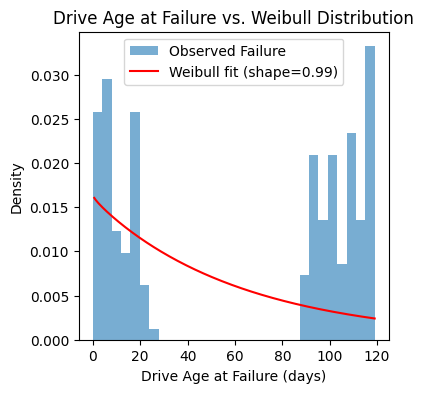

In [115]:
from scipy import stats
import matplotlib.pyplot as plt

failed_ages = df[df['failure'] == 1]['drive_age_days']

shape, loc, scale = stats.weibull_min.fit(failed_ages, floc=0)

x = np.linspace(0, failed_ages.max(), 200)
pdf_fitted = stats.weibull_min.pdf(x, shape, loc, scale)

plt.figure(figsize=(4,4))
plt.hist(failed_ages, bins=30, density=True, alpha=0.6, label='Observed Failure')
plt.plot(x, pdf_fitted, 'r-', label= f'Weibull fit (shape={shape:.2f})')
plt.xlabel('Drive Age at Failure (days)')
plt.ylabel('Density')
plt.title('Drive Age at Failure vs. Weibull Distribution')
plt.legend()
plt.savefig('/kaggle/working/images/weibull_drive_age.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP

## SHAP: A Bathtub Curve?

In [116]:
import shap
failures = X_test[y_test == 1]
healthy_sample = X_test[y_test == 0].sample(n=2000, random_state=42)
X_shap_sample = pd.concat([failures, healthy_sample])

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap_sample)

In [117]:
shap_values_failure = shap_values[:, :, 1]
print(shap_values_failure.shape)  # should be (n_samples, n_features)

(3961, 39)


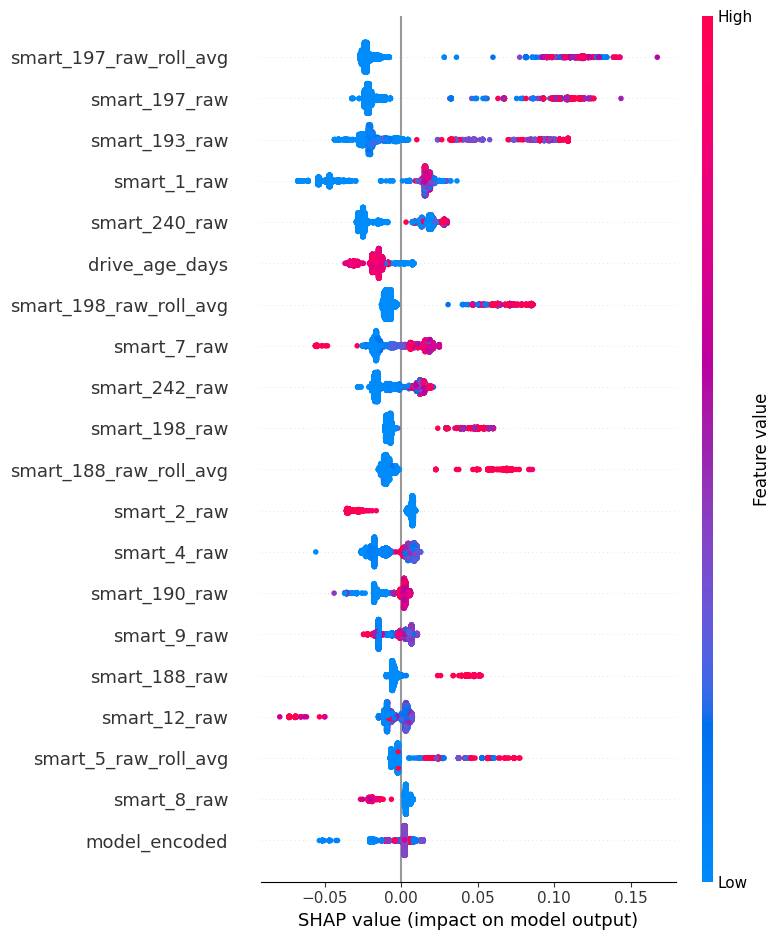

In [118]:
shap.summary_plot(shap_values_failure, X_shap_sample, feature_names=X_shap_sample.columns, show=False)
plt.savefig('/kaggle/working/images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP: Digging Deeper

Axes(0.125,0.11;0.775x0.77)


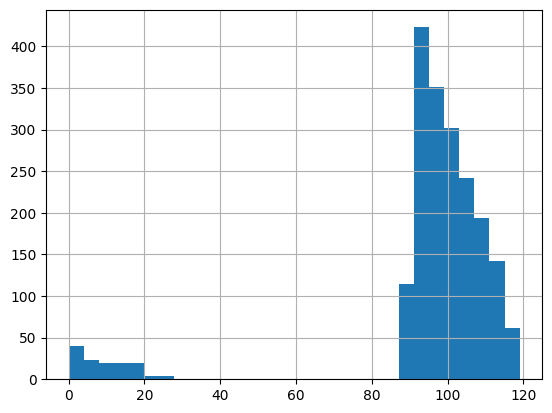

In [119]:
print(failures['drive_age_days'].hist(bins=30))

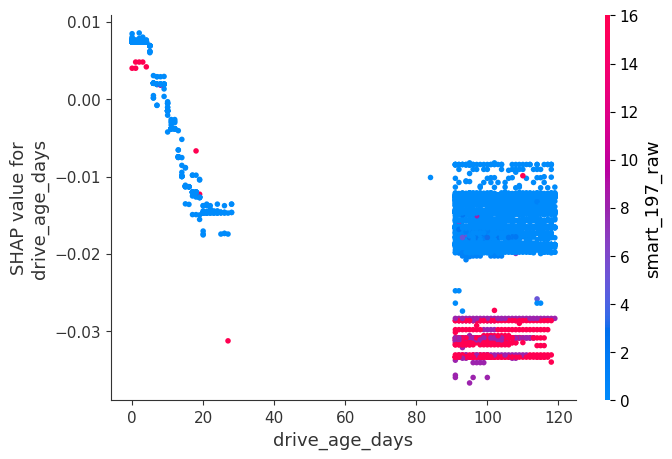

In [120]:
shap.dependence_plot('drive_age_days', shap_values_failure, X_shap_sample, show=False)
plt.savefig('/kaggle/working/images/shap_dependence_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [122]:
import joblib
joblib.dump(best_rf, '/kaggle/working/final_rf_model.pkl')
joblib.dump(feature_cols, '/kaggle/working/feature_cols.pkl')
joblib.dump(le, '/kaggle/working/label_encoder.pkl')
joblib.dump(0.5, '/kaggle/working/threshold.pkl')

['/kaggle/working/threshold.pkl']